# Potential Talents — Candidate Ranking
## Notebook 01 — Data and Rule-Based Relevance

This notebook builds the **transparent rule-based reference procedure** for the two recruiter searches:

- `aspiring human resources`
- `seeking human resources`

The source file contains 104 candidate rows but only **52 unique `job_title` values**. Ranking is therefore evaluated once per unique title so repeated titles cannot receive extra weight. The independent 0–3 human labels are used **only after the algorithm is defined**, as a validation audit; they are not used to fit Word2Vec or to construct the rule scores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from IPython.display import display

SOURCE = "potential-talents.csv"
LABELS = "unique-job-titles-labelled.csv"

source = pd.read_csv(SOURCE)
labels = pd.read_csv(LABELS)

assert list(source.columns) == ["id","job_title","location","connection","fit"]
assert len(source) == 104
assert source["id"].is_unique
assert source["job_title"].nunique() == 52
assert len(labels) == 52
assert labels["job_title"].is_unique
assert labels["manual_relevance_grade"].isin([0,1,2,3]).all()

summary = pd.DataFrame({
    "quantity": ["source rows", "unique job titles", "independent human-labelled titles"],
    "value": [len(source), source["job_title"].nunique(), len(labels)],
})
display(summary)


,quantity,value
0,source rows,104
1,unique job titles,52
2,independent human-labelled titles,52


### Dataset structure and vocabulary

Before defining the relevance rules, the title field is audited for duplication and vocabulary structure. This matters because repeated titles can distort frequency-based evidence, while the mix of frequent target terms and sparse HR-adjacent vocabulary determines whether exact rules alone are sufficient.

,job_title,source_rows
0,2019 C.T. Bauer College of Business Graduate (...,7
1,Aspiring Human Resources Professional,7
2,Student at Humber College and Aspiring Human R...,7
3,People Development Coordinator at Ryan,6
4,Native English Teacher at EPIK (English Progra...,5
5,Aspiring Human Resources Specialist,5
6,HR Senior Specialist,5
7,Advisory Board Member at Celal Bayar University,4
8,Seeking Human Resources HRIS and Generalist Po...,4
9,Student at Chapman University,4


,signal,unique_titles,share_of_52
0,Human Resources phrase,31,59.6%
1,Direct HR evidence,34,65.4%
2,aspiring,12,23.1%
3,seeking,10,19.2%
4,professional,8,15.4%
5,manager,7,13.5%
6,generalist,5,9.6%
7,management,5,9.6%
8,specialist,4,7.7%


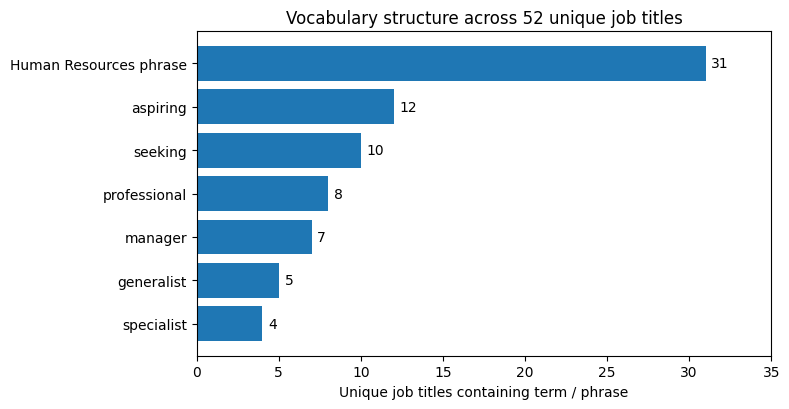

CHECKPOINT {'repeated_unique_titles': 14, 'max_exact_title_frequency': 7, 'human_resources_phrase_titles': 31, 'direct_hr_evidence_titles': 34, 'aspiring_titles': 12, 'seeking_titles': 10}


In [2]:
import re
from collections import Counter

# Exact-title repetition in the original 104 rows.
title_frequency = source["job_title"].value_counts()
unique_titles = source.drop_duplicates("job_title", keep="first")[["id","job_title"]].reset_index(drop=True)
assert len(unique_titles) == 52
assert int((title_frequency > 1).sum()) == 14
assert int((title_frequency == 1).sum()) == 38
assert title_frequency.iloc[:3].tolist() == [7, 7, 7]

# Title-level lexical prevalence. Counting each unique title once prevents the repeated
# early records from inflating words such as "aspiring" and "professional".
def simple_title_tokens(text):
    return re.findall(r"[A-Za-z]+", str(text).lower())

def title_contains_word(title, word):
    return bool(re.search(rf"\b{re.escape(word)}\b", str(title), flags=re.I))

def title_contains_phrase(title, phrase):
    normalized = re.sub(r"[^a-z0-9]+", " ", str(title).lower())
    normalized = re.sub(r"\s+", " ", normalized).strip()
    return phrase in normalized

def direct_hr_evidence_for_audit(title):
    normalized = re.sub(r"[^a-z0-9]+", " ", str(title).lower())
    normalized = re.sub(r"\s+", " ", normalized).strip()
    tokens = set(normalized.split())
    return (
        "human resources" in normalized
        or "hr" in tokens
        or "hris" in tokens
        or "chro" in tokens
        or "gphr" in tokens
        or "sphr" in tokens
    )

signals = {
    "Human Resources phrase": sum(title_contains_phrase(t, "human resources") for t in unique_titles["job_title"]),
    "Direct HR evidence": sum(direct_hr_evidence_for_audit(t) for t in unique_titles["job_title"]),
    "aspiring": sum(title_contains_word(t, "aspiring") for t in unique_titles["job_title"]),
    "seeking": sum(title_contains_word(t, "seeking") for t in unique_titles["job_title"]),
    "professional": sum(title_contains_word(t, "professional") for t in unique_titles["job_title"]),
    "manager": sum(title_contains_word(t, "manager") for t in unique_titles["job_title"]),
    "generalist": sum(title_contains_word(t, "generalist") for t in unique_titles["job_title"]),
    "management": sum(title_contains_word(t, "management") for t in unique_titles["job_title"]),
    "specialist": sum(title_contains_word(t, "specialist") for t in unique_titles["job_title"]),
}
expected_signals = {
    "Human Resources phrase": 31, "Direct HR evidence": 34,
    "aspiring": 12, "seeking": 10, "professional": 8,
    "manager": 7, "generalist": 5, "management": 5, "specialist": 4,
}
assert signals == expected_signals, signals

adjacent_terms = ["staffing","recruiting","recruiter","talent","payroll","benefits","compensation"]
adjacent_counts = {
    term: sum(title_contains_word(t, term) for t in unique_titles["job_title"])
    for term in adjacent_terms
}
assert adjacent_counts == {
    "staffing":2, "recruiting":1, "recruiter":1,
    "talent":1, "payroll":1, "benefits":1, "compensation":1,
}

repeated = title_frequency.head(10).rename_axis("job_title").reset_index(name="source_rows")
signal_table = pd.DataFrame({
    "signal": list(signals.keys()),
    "unique_titles": list(signals.values()),
})
signal_table["share_of_52"] = signal_table["unique_titles"] / 52

display(repeated)
display(signal_table.style.format({"share_of_52":"{:.1%}"}))

# Compact visual for the most decision-relevant vocabulary.
plot_signals = ["Human Resources phrase","aspiring","seeking","professional","manager","generalist","specialist"]
fig, ax = plt.subplots(figsize=(8,4.2))
vals = [signals[k] for k in plot_signals]
ax.barh(plot_signals[::-1], vals[::-1])
ax.set_xlabel("Unique job titles containing term / phrase")
ax.set_title("Vocabulary structure across 52 unique job titles")
for y, v in enumerate(vals[::-1]):
    ax.text(v + 0.35, y, str(v), va="center")
ax.set_xlim(0, max(vals)+4)
plt.tight_layout()
plt.show()

print("CHECKPOINT", {
    "repeated_unique_titles": int((title_frequency > 1).sum()),
    "max_exact_title_frequency": int(title_frequency.max()),
    "human_resources_phrase_titles": signals["Human Resources phrase"],
    "direct_hr_evidence_titles": signals["Direct HR evidence"],
    "aspiring_titles": signals["aspiring"],
    "seeking_titles": signals["seeking"],
})

Across the 104 source rows, **14 of the 52 unique titles repeat**, and the three most frequent exact titles each occur **7 times**. After counting each title once, **31/52 (59.6%)** explicitly contain *Human Resources* and **34/52 (65.4%)** contain direct HR evidence once standalone HR/CHRO-style signals are included. The target intent words are also common but not universal: **12 titles contain _aspiring_** and **10 contain _seeking_**. Other frequent HR descriptors include *professional* (8 titles), *manager* (7), *generalist* (5), *management* (5), and *specialist* (4), while adjacent signals such as *staffing* (2) and recruiting/recruiter, talent, payroll, benefits, and compensation (1 each) are sparse. This structure justifies the hybrid design: explicit role and intent terms provide transparent evidence for the rule-based reference, while Word2Vec is useful because relevant HR language is varied and many related terms are too infrequent for exact keyword matching alone. Deduplicating titles before evaluation also prevents repeated phrases from dominating the metrics.

### Rule design

The algorithm deliberately separates **occupational relevance** from **search intent**:

\[
R = H(0.70 + 0.30I)
\]

- **H = 1.0** for direct HR evidence such as *Human Resources*, standalone *HR*, *HRIS*, or *CHRO*.
- **H = 0.5** for defensible adjacent functions such as people development, recruiting, staffing, talent, benefits, or compensation when no direct HR term is present.
- **H = 0** when there is no defensible HR evidence.
- **I = 1.0** when the title contains the active intent (*aspiring* or *seeking*), **0.5** for the opposite target intent, and **0** otherwise.
- A directionality safeguard forces clear employer solicitations (for example, a staffing company *seeking HR professionals*) to zero.

The multiplication is important: generic intent language cannot manufacture occupational relevance.

In [3]:
import re
import numpy as np
import pandas as pd

QUERIES = ("aspiring human resources", "seeking human resources")

_DIRECT_HR = re.compile(r"\bhuman\s+resources\b|\bhr\b|\bhris\b|\bchro\b", re.I)
_ADJACENT_HR = re.compile(
    r"\bpeople\s+development\b|\btalent\s+(?:acquisition|management)\b|"
    r"\bstaffing\b|\brecruit(?:er|ing|ment)\b|\bbenefits\b|\bcompensation\b",
    re.I,
)
_EMPLOYER_SOLICITATION = re.compile(
    r"\b(?:is|are)\s+seeking\b.*\b(?:professionals?|candidates?|applicants?)\b",
    re.I,
)

def occupational_relevance(title):
    """H in {0, 0.5, 1}: none, adjacent, or direct HR evidence."""
    title = str(title)
    if _EMPLOYER_SOLICITATION.search(title):
        return 0.0
    if _DIRECT_HR.search(title):
        return 1.0
    if _ADJACENT_HR.search(title):
        return 0.5
    return 0.0

def intent_alignment(title, query):
    """I in {0, 0.5, 1}: neutral, opposite target intent, or active target intent."""
    title_l = str(title).lower()
    query_l = str(query).lower()
    target = "aspiring" if "aspiring" in query_l else "seeking"
    other = "seeking" if target == "aspiring" else "aspiring"
    if target in title_l:
        return 1.0
    if other in title_l:
        return 0.5
    return 0.0

def rule_score(title, query):
    """Transparent query-specific relevance: R = H(0.70 + 0.30I)."""
    H = occupational_relevance(title)
    I = intent_alignment(title, query)
    return H * (0.70 + 0.30 * I)

def rule_level(title):
    """Query-independent ordinal level used only for the human-vs-rule validation."""
    H = occupational_relevance(title)
    if H == 0:
        return 0
    if H < 1:
        return 1
    title_l = str(title).lower()
    return 3 if ("aspiring" in title_l or "seeking" in title_l) else 2


query,aspiring human resources,seeking human resources
rule_score,,
0.00,18,18
0.35,1,1
0.70,16,16
0.85,5,9
1.00,12,8


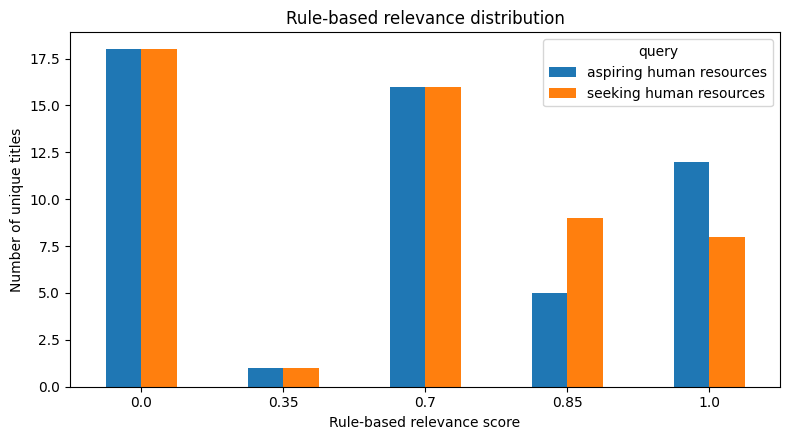

In [4]:
rule_rows = []
for _, row in labels.iterrows():
    for query in QUERIES:
        rule_rows.append({
            "representative_id": int(row["representative_id"]),
            "job_title": row["job_title"],
            "query": query,
            "H": occupational_relevance(row["job_title"]),
            "I": intent_alignment(row["job_title"], query),
            "rule_score": rule_score(row["job_title"], query),
        })
rule = pd.DataFrame(rule_rows)

expected_distributions = {
    "aspiring human resources": {0.00:18, 0.35:1, 0.70:16, 0.85:5, 1.00:12},
    "seeking human resources": {0.00:18, 0.35:1, 0.70:16, 0.85:9, 1.00:8},
}
for query, expected in expected_distributions.items():
    observed = rule.loc[rule["query"].eq(query), "rule_score"].round(2).value_counts().sort_index().to_dict()
    assert observed == expected, (query, observed)

pivot = (
    rule.assign(rule_score=rule["rule_score"].round(2))
        .groupby(["rule_score","query"]).size().unstack(fill_value=0)
)
display(pivot)

ax = pivot.plot(kind="bar", figsize=(8,4.5))
ax.set_title("Rule-based relevance distribution")
ax.set_xlabel("Rule-based relevance score")
ax.set_ylabel("Number of unique titles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Independent human → algorithm check

The human labels are now compared with a **query-independent ordinal interpretation of the already-defined rule system**:

- level 0: no occupational relevance,
- level 1: adjacent relevance,
- level 2: direct HR relevance without explicit target intent,
- level 3: direct HR relevance with *aspiring* or *seeking* intent.

This check is validation-only; no label is fed back into the algorithm.

,validation metric,result
0,Exact ordinal agreement,39/52 = 75.0%
1,Quadratic weighted Cohen's kappa,0.888
2,Spearman correlation,0.871


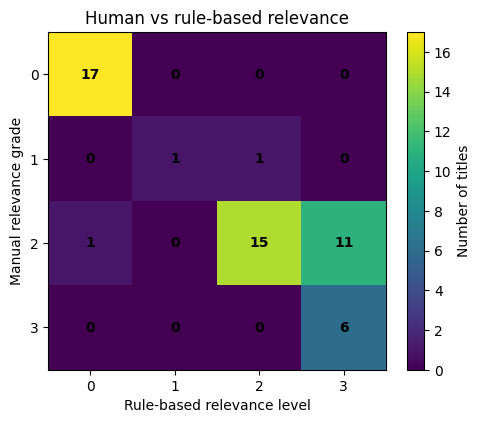

CHECKPOINT {'source_rows': 104, 'unique_titles': 52, 'exact_agreement': 0.75, 'quadratic_weighted_kappa': 0.888, 'spearman': 0.871}


In [5]:
validation = labels.copy()
validation["rule_relevance_level"] = validation["job_title"].map(rule_level)

y_true = validation["manual_relevance_grade"].to_numpy()
y_rule = validation["rule_relevance_level"].to_numpy()

cm = confusion_matrix(y_true, y_rule, labels=[0,1,2,3])
exact_count = int((y_true == y_rule).sum())
exact_pct = exact_count / len(validation)
kappa = cohen_kappa_score(y_true, y_rule, weights="quadratic")
rho = spearmanr(y_true, y_rule).statistic

assert exact_count == 39
assert np.isclose(exact_pct, 0.75)
assert np.isclose(kappa, 0.8880516684607105)
assert np.isclose(rho, 0.8713813631881077)
assert cm.tolist() == [[17,0,0,0],[0,1,1,0],[1,0,15,11],[0,0,0,6]]

metrics = pd.DataFrame({
    "validation metric": ["Exact ordinal agreement", "Quadratic weighted Cohen's kappa", "Spearman correlation"],
    "result": [f"{exact_count}/52 = {exact_pct:.1%}", f"{kappa:.3f}", f"{rho:.3f}"],
})
display(metrics)

fig, ax = plt.subplots(figsize=(5,4.2))
im = ax.imshow(cm)
ax.set_xticks(range(4), [0,1,2,3])
ax.set_yticks(range(4), [0,1,2,3])
ax.set_xlabel("Rule-based relevance level")
ax.set_ylabel("Manual relevance grade")
ax.set_title("Human vs rule-based relevance")
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i,j], ha="center", va="center", fontweight="bold")
fig.colorbar(im, ax=ax, label="Number of titles")
plt.tight_layout()
plt.show()

print("CHECKPOINT", {
    "source_rows": len(source),
    "unique_titles": len(labels),
    "exact_agreement": round(exact_pct, 3),
    "quadratic_weighted_kappa": round(float(kappa), 3),
    "spearman": round(float(rho), 3),
})
